In [2]:
#load the toll
import pandas as pd
import matplotlib.pyplot as plt

#load the data
df=pd.read_csv("../data/creditcard.csv")
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
#size of the table
df.shape


(284807, 31)

In [4]:
#how many fraud count normal(0) vs fraud(1)
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [8]:
#percentage fraud
fraud_rate=df["Class"].mean()*100
print(f"fraud_rate:{fraud_rate:.2f}%")

fraud_rate:0.17%


In [11]:
# total number of empty cells in the whole table
df.isna().sum().sum()

np.int64(0)

In [12]:
# rows that are exact copies of an earlier row
df.duplicated().sum()

np.int64(1081)

In [15]:
# how many of the duplicate rows are fraud?
dups = df[df.duplicated()]
dups["Class"].value_counts()

Class
0    1062
1      19
Name: count, dtype: int64

In [17]:
# remove duplicate rows and check the new size
df = df.drop_duplicates()
print("Rows after removing duplicates:", len(df))
print("Frauds after removing duplicates:", df["Class"].sum())

Rows after removing duplicates: 283726
Frauds after removing duplicates: 473


In [26]:
#compare amounts for normal vs fraud
Fraud_total=df[df["Class"] == 1]["Amount"].sum()
print(f"Fraud_total:{Fraud_total:.2f}")

Fraud_total:58591.39


In [28]:
#Show statistics for each class side by side
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


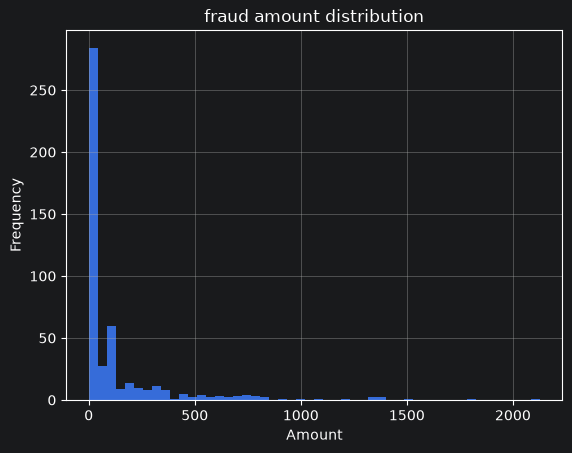

In [29]:
#draw histogram
df[df["Class"] == 1]["Amount"].hist(bins=50)
plt.title("Fraud amount distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

In [36]:
#find out whether fraud happens more at certain hours of the day
## convert seconds into hour of the day (0-23)
df["Hour"] = ((df["Time"] // 3600) % 24).astype(int)
df[["Time", "Hour"]].head(10)


,Time,Hour
0,0.0,0
1,0.0,0
2,1.0,0
3,1.0,0
4,2.0,0
5,2.0,0
6,4.0,0
7,7.0,0
8,7.0,0
9,9.0,0


In [45]:
# for each hour (0-23), count how many frauds happened
fraud_by_hour = df[df["Class"] == 1]["Hour"].value_counts().sort_index()
fraud_by_hour

Hour
0      6
1     10
2     48
3     17
4     23
5     11
6      9
7     23
8      9
9     16
10     8
11    53
12    17
13    17
14    23
15    26
16    22
17    28
18    28
19    19
20    18
21    16
22     9
23    17
Name: count, dtype: int64

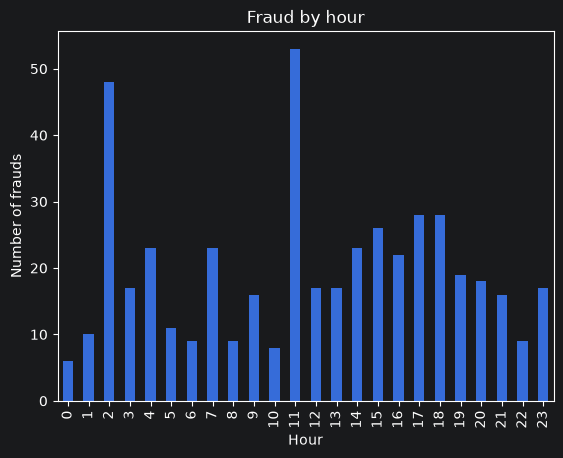

In [46]:
#bar chart
fraud_by_hour.plot(kind="bar")
plt.title("Fraud by hour")
plt.ylabel("Number of frauds")
plt.xlabel("Hour")
plt.show()

In [49]:
#the percentage of purchases that are fraud, for each hour
fraud_rate_by_hour= round(df.groupby("Hour")  ["Class"]  .mean() * 100,2)
fraud_rate_by_hour

Hour
0     0.08
1     0.24
2     1.45
3     0.49
4     1.04
5     0.37
6     0.22
7     0.32
8     0.09
9     0.10
10    0.05
11    0.32
12    0.11
13    0.11
14    0.14
15    0.16
16    0.13
17    0.17
18    0.17
19    0.12
20    0.11
21    0.09
22    0.06
23    0.16
Name: Class, dtype: float64

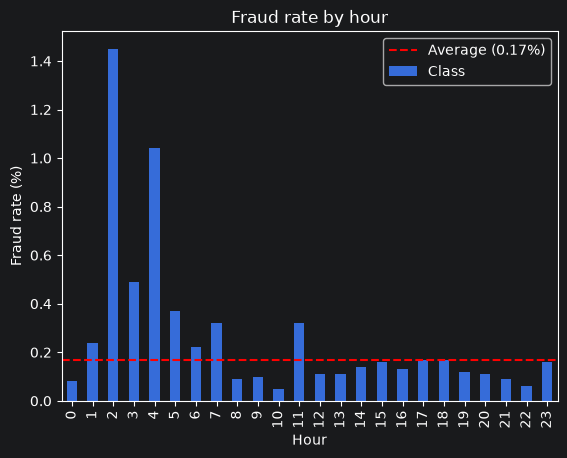

In [52]:
#rate chart
fraud_rate_by_hour.plot(kind="bar")
plt.title("Fraud rate by hour")
plt.ylabel("Fraud rate (%)")
plt.xlabel("Hour")
plt.axhline(0.17, color="red", linestyle="--", label="Average (0.17%)")
plt.legend()
plt.show()
